<a href="https://colab.research.google.com/github/christianmfenner/Wiper_blades_analysis/blob/main/An%C3%A1lise_Palhetas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise

# 1. Histórico de busca 'Palhetas'

In [ ]:
pip install pytrends

In [ ]:
from pytrends.request import TrendReq
import pandas as pd

pytrends = TrendReq(hl='pt-BR', tz=360)

palavras_chave = ["palheta"]
pytrends.build_payload(palavras_chave, cat=0, timeframe='today 3-m', geo='BR-SP')

dados = pytrends.interest_over_time()

df_palheta = pd.DataFrame(dados)

df_palheta


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,palheta,isPartial
date,,
2025-06-16,49,False
2025-06-17,68,False
2025-06-18,46,False
2025-06-19,41,False
2025-06-20,56,False
...,...,...
2025-09-12,60,False
2025-09-13,66,False
2025-09-14,48,False


In [ ]:
from pytrends.request import TrendReq
import pandas as pd
from datetime import datetime, timedelta

#Configuração inicial
pytrends = TrendReq(hl='pt-BR', tz=360)
palavras_chave = ["palheta"]
inicio = datetime(2010, 1, 1)
hoje = datetime.today()
delta = timedelta(days=90)

#Lista para armazenar os dados
dfs = []

#Loop para buscar dados trimestrais
while inicio < hoje:
  fim = inicio + delta
  if fim > hoje:
    fim = hoje

  # Formata datas no padrão do Google Trends
  timeframe = f"{inicio.strftime('%Y-%m-%d')} {fim.strftime('%Y-%m-%d')}"
  print(f"Coletando dados de: {timeframe}")

  pytrends.build_payload(palavras_chave, cat=0, timeframe=timeframe, geo='BR-SP')
  dados = pytrends.interest_over_time()

  # Verifica se dados foram retornados
  if not dados.empty:
      dfs.append(dados.reset_index())

  inicio = fim + timedelta(days=1)

df_palheta = pd.concat(dfs, ignore_index=True)

if 'isPartial' in df_palheta.columns:
    df_palheta = df_palheta.drop(columns=['isPartial'])

df_palheta

Coletando dados de: 2010-01-01 2010-04-01
Coletando dados de: 2010-04-02 2010-07-01
Coletando dados de: 2010-07-02 2010-09-30
Coletando dados de: 2010-10-01 2010-12-30
Coletando dados de: 2010-12-31 2011-03-31
Coletando dados de: 2011-04-01 2011-06-30
Coletando dados de: 2011-07-01 2011-09-29
Coletando dados de: 2011-09-30 2011-12-29
Coletando dados de: 2011-12-30 2012-03-29
Coletando dados de: 2012-03-30 2012-06-28
Coletando dados de: 2012-06-29 2012-09-27
Coletando dados de: 2012-09-28 2012-12-27
Coletando dados de: 2012-12-28 2013-03-28
Coletando dados de: 2013-03-29 2013-06-27
Coletando dados de: 2013-06-28 2013-09-26
Coletando dados de: 2013-09-27 2013-12-26
Coletando dados de: 2013-12-27 2014-03-27
Coletando dados de: 2014-03-28 2014-06-26
Coletando dados de: 2014-06-27 2014-09-25
Coletando dados de: 2014-09-26 2014-12-25
Coletando dados de: 2014-12-26 2015-03-26
Coletando dados de: 2015-03-27 2015-06-25
Coletando dados de: 2015-06-26 2015-09-24
Coletando dados de: 2015-09-25 201

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,date,palheta
0,2010-04-02,0
1,2010-04-03,0
2,2010-04-04,0
3,2010-04-05,0
4,2010-04-06,0
...,...,...
5642,2025-09-12,88
5643,2025-09-13,98
5644,2025-09-14,71
5645,2025-09-15,85


# 2. Previsão de chuva

In [ ]:
import requests
import pandas as pd

base = 'https://api.hgbrasil.com/'

rota = 'weather?'

woeid = '455827' #id de São Paulo

chave = '3b9b39d6'#chave única do usuário

parametro = f'woeid={woeid}&key={chave}'

url = base+rota+parametro


resultado = requests.get(url)

forecast_api = resultado.json()['results']['forecast']

df_prev = pd.DataFrame(forecast_api)

df_prev_rain = df_prev[['full_date','rain']]

df_prev_rain

url

'https://api.hgbrasil.com/weather?woeid=455827&key=3b9b39d6'

# 3. Histórico de chuva São Paulo

In [ ]:
import pandas as pd
import requests
from datetime import date, timedelta

# Datas
hoje = date.today()
#inicio = hoje - timedelta(days=365)
inicio = date(2011,1,1)

# Cidades com coordenadas e população
cidades = {
    "São Paulo": {"lat": -23.55, "lon": -46.63, "pop": 12.3},
    "Guarulhos": {"lat": -23.46, "lon": -46.53, "pop": 1.4},
    "Campinas": {"lat": -22.90, "lon": -47.06, "pop": 1.2},
    "São Bernardo": {"lat": -23.69, "lon": -46.56, "pop": 0.84},
    "Santo André": {"lat": -23.66, "lon": -46.53, "pop": 0.72},
    "Osasco": {"lat": -23.53, "lon": -46.79, "pop": 0.7},
    "Sorocaba": {"lat": -23.50, "lon": -47.45, "pop": 0.7},
    "Ribeirão Preto": {"lat": -21.17, "lon": -47.81, "pop": 0.74},
}

# Lista para armazenar os DataFrames
dfs = []

# Consulta para cada cidade
for cidade, info in cidades.items():
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": info["lat"],
        "longitude": info["lon"],
        "start_date": inicio.isoformat(),
        "end_date": hoje.isoformat(),
        "daily": "precipitation_sum",
        "timezone": "America/Sao_Paulo"
    }
    r = requests.get(url, params=params)
    if r.status_code == 200:
        data = r.json()
        df = pd.DataFrame({
            "data": pd.to_datetime(data["daily"]["time"]),
            cidade: data["daily"]["precipitation_sum"]
        })
        dfs.append(df)
    else:
        print(f"Erro ao consultar {cidade}")

# Junta tudo por data
df_final = dfs[0]
for df in dfs[1:]:
    df_final = df_final.merge(df, on="data", how="inner")

# Calcula a média ponderada por população
populacoes = [info["pop"] for info in cidades.values()]
colunas = list(cidades.keys())
df_final["chuva_ponderada_mm"] = df_final[colunas].mul(populacoes).sum(axis=1) / sum(populacoes)

# Resultado final




df_final = df_final[["data", "chuva_ponderada_mm"]]

df_final


,data,chuva_ponderada_mm
0,2011-01-01,4.382903
1,2011-01-02,40.415161
2,2011-01-03,29.405054
3,2011-01-04,33.392796
4,2011-01-05,5.762258
...,...,...
5368,2025-09-12,0.008387
5369,2025-09-13,0.019355
5370,2025-09-14,0.000000
5371,2025-09-15,0.000000


# 4. Join da Tabela de Trend com a Tabela de Histórico de precipitação

Fazer o lag aqui '.shift()' - Antes e depois do groupby

No Google Trends e na precipitação

Columns in df_palheta: Index(['date', 'palheta'], dtype='object')
Columns in df_hist_rain: Index(['date', 'chuva_ponderada_mm'], dtype='object')


<Axes: xlabel='chuva_ponderada_mm', ylabel='palheta'>

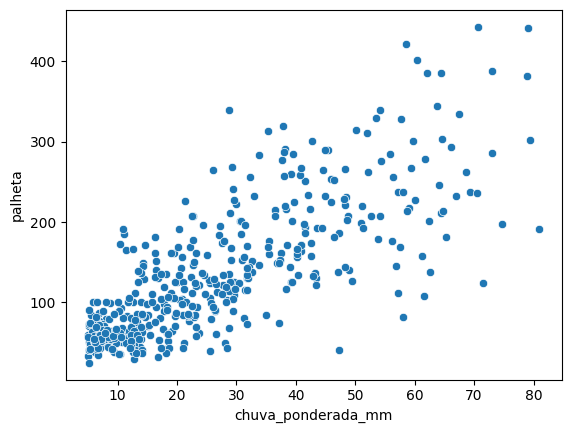

In [ ]:
# Converter os índices em coluna no df_palheta, se necessário
if df_palheta.index.name == 'date':
    df_palheta = df_palheta.reset_index()

# Converter as colunas para datetime
df_palheta['date'] = pd.to_datetime(df_palheta['date'])

# Rename the 'data' column to 'date' in df_hist_rain
df_final.rename(columns={'data': 'date'}, inplace=True)

# Convert the 'date' column to datetime in df_hist_rain after renaming
df_final['date'] = pd.to_datetime(df_final['date'])


# Print column names before merge for debugging
print("Columns in df_palheta:", df_palheta.columns)
print("Columns in df_hist_rain:", df_final.columns)

# Realizar o join com base na coluna 'date'
df_joined = pd.merge(df_palheta, df_final, on='date', how='inner')

# Remover a coluna 'isPartial' se existir
if 'isPartial' in df_joined.columns:
    df_joined = df_joined.drop(columns=['isPartial'])


# # Adicionar uma coluna com o número da semana e o ano (para evitar ambiguidades entre anos)
df_joined['ano_semana'] = df_joined['date'].dt.strftime('%Y-%U')  # %U usa domingo como início da semana

df_joined.drop(df_joined[df_joined['chuva_ponderada_mm'] < 5].index, inplace=True)
df_joined.drop(df_joined[df_joined['palheta'] == 0].index, inplace=True)

# Exibir resultado
df_joined[['ano_semana','palheta','chuva_ponderada_mm']]

# Agrupar por 'ano_semana' e somar as colunas numéricas
df_grouped = df_joined.groupby('ano_semana', as_index=False).sum(numeric_only=True)

# Exibir o resultado agrupado
new_df_joined = df_grouped[['ano_semana', 'palheta', 'chuva_ponderada_mm']]

new_df_joined.set_index('ano_semana', inplace=True)

import seaborn as sns


#new_df_joined.to_csv("new_df_joined_2010.csv", index=True)

# df_joined.to_csv("df_joined_limpo4.csv", index=True)

#Remoção de outliers

Q1 = new_df_joined['chuva_ponderada_mm'].quantile(.25)

Q3 = new_df_joined['chuva_ponderada_mm'].quantile(.75)

IIQ = Q3 - Q1

L_inf = Q1 - 1.5*IIQ

L_sup = Q3 + 1.5*IIQ

new_df_joined.drop(new_df_joined[new_df_joined['chuva_ponderada_mm'] > L_sup].index, inplace=True)

new_df_joined

sns.scatterplot(y=new_df_joined['palheta'],x=new_df_joined['chuva_ponderada_mm'])




In [ ]:
new_df_joined.corr()

,palheta,chuva_ponderada_mm
palheta,1.000000,0.785363
chuva_ponderada_mm,0.785363,1.000000


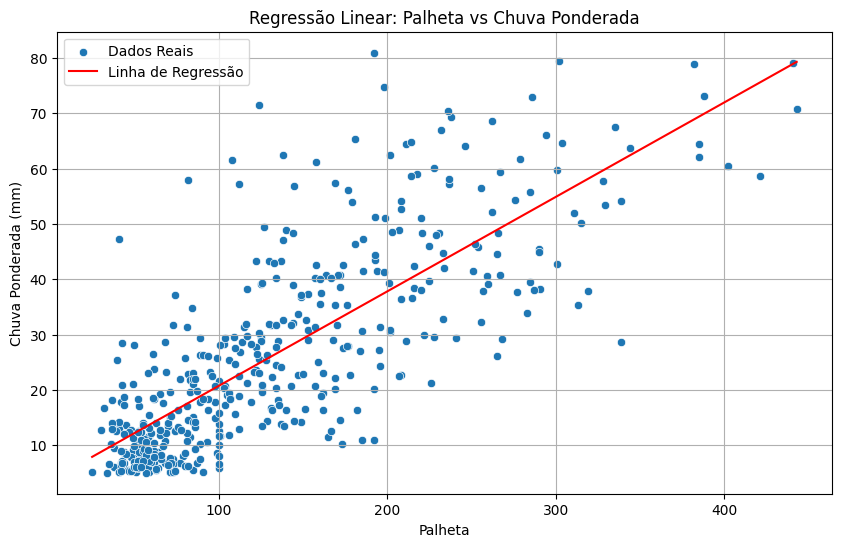

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Preparar os dados para o modelo
X = new_df_joined['palheta'].values.reshape(-1, 1)
y = new_df_joined['chuva_ponderada_mm'].values

# Ajustar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Gerar os valores previstos
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = modelo.predict(x_range)

# Plotar scatter com a linha de regressão
plt.figure(figsize=(10,6))
sns.scatterplot(x=new_df_joined['palheta'], y=new_df_joined['chuva_ponderada_mm'], label='Dados Reais')
plt.plot(x_range, y_pred, color='red', label='Linha de Regressão')  # Linha prevista
plt.xlabel('Palheta')
plt.ylabel('Chuva Ponderada (mm)')
plt.title('Regressão Linear: Palheta vs Chuva Ponderada')
plt.legend()
plt.grid(True)
plt.show()

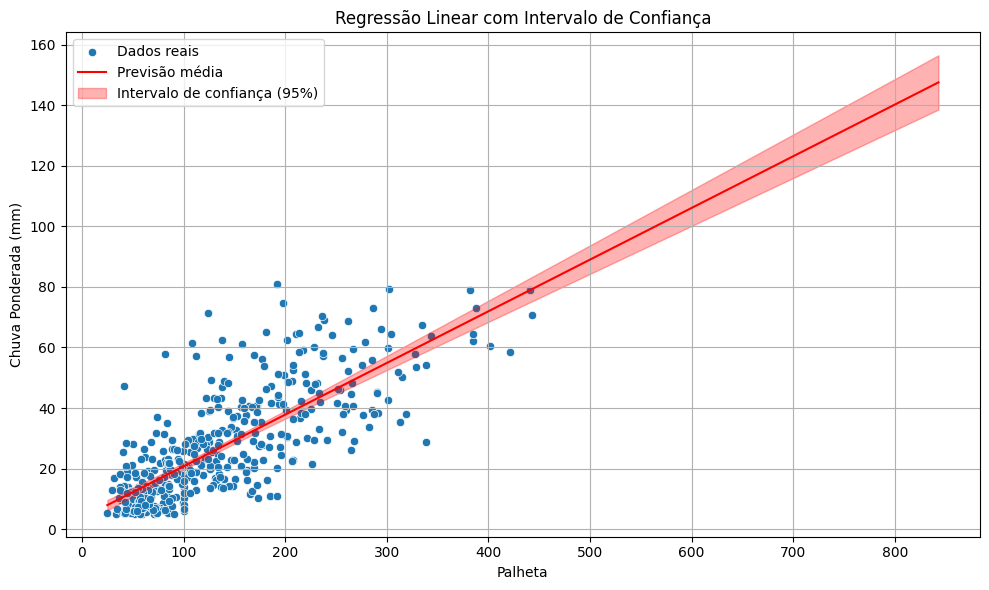

In [ ]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dados
X = new_df_joined['palheta'].values
y = new_df_joined['chuva_ponderada_mm'].values

# Adiciona constante para o modelo (intercepto)
X_sm = sm.add_constant(X)

# Ajusta o modelo OLS (Ordinary Least Squares)
modelo = sm.OLS(y, X_sm).fit()

# Criar novos valores de X estendidos além do intervalo atual
x_min = X.min()  # estende um pouco para a esquerda
x_max = X.max() + 400  # estende um pouco para a direita
x_range = np.linspace(x_min, x_max, 200)
x_range_sm = sm.add_constant(x_range)  # precisa da constante para o modelo

# Prever com intervalo de confiança
preds = modelo.get_prediction(x_range_sm)
pred_summary = preds.summary_frame(alpha=0.05)  # 95% intervalo de confiança

# Plotar gráfico
plt.figure(figsize=(10,6))
sns.scatterplot(x=X, y=y, label='Dados reais')

# Linha de predição
plt.plot(x_range, pred_summary['mean'], color='red', label='Previsão média')

# Faixa de intervalo de confiança
plt.fill_between(x_range,
                 pred_summary['mean_ci_lower'],
                 pred_summary['mean_ci_upper'],
                 color='red', alpha=0.3, label='Intervalo de confiança (95%)')

plt.xlabel('Palheta')
plt.ylabel('Chuva Ponderada (mm)')
plt.title('Regressão Linear com Intervalo de Confiança')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

4. Treinamento

0.3092940620007953

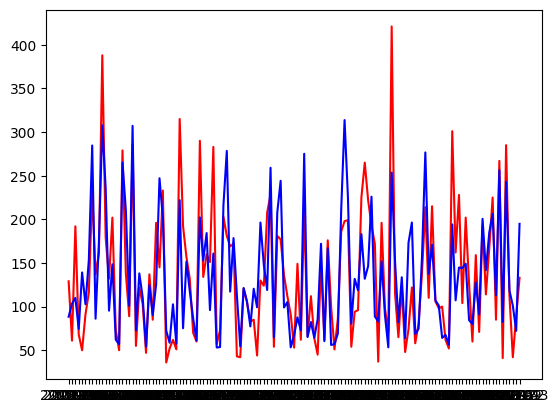

In [ ]:
#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression

#Outros
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Continua o resto do código normalmente
X = new_df_joined[['chuva_ponderada_mm']]  # Seleciona como DataFrame
y = new_df_joined['palheta']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=44)

modelo = LinearRegression()

modelo.fit(x_train, y_train)

y_pred = modelo.predict(x_test)


#metrics.accuracy_score(y_test, y_pred)

metrics.mean_absolute_percentage_error(y_test, y_pred)

# df_joined.to_csv("df_joined_limpo4.csv", index=True)

plt.plot(y_test, color = 'red');
plt.plot(y_pred, color = 'blue');
metrics.mean_absolute_percentage_error(y_test, y_pred)

[ 4.52928232 -0.01140399]
MAPE: 0.3105


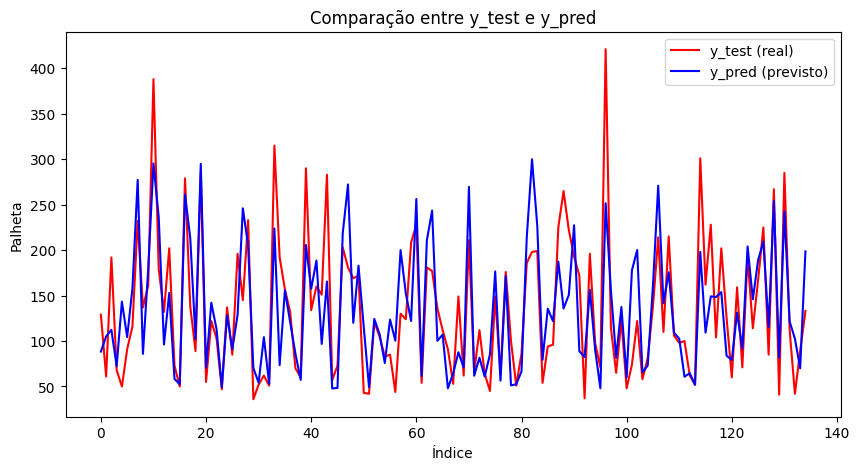

In [ ]:
#Modelos
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

#Outros
from sklearn import metrics
from sklearn.metrics import r2_score

# Dados
X = new_df_joined[['chuva_ponderada_mm']]  # Seleciona como DataFrame
y = new_df_joined['palheta']

# Gerando os dados polinomiais
poly_features = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Separando em treino e teste
x_train, x_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=44)

# Treinando o modelo
model = LinearRegression()
model.fit(x_train, y_train)

print(model.coef_)

# Fazendo predições no conjunto de teste
y_pred = model.predict(x_test)

# Avaliação
mape = metrics.mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.4f}")

# Gráfico ajustado
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='y_test (real)', color='red')
plt.plot(y_pred, label='y_pred (previsto)', color='blue')
plt.legend()
plt.title("Comparação entre y_test e y_pred")
plt.xlabel("Índice")
plt.ylabel("Palheta")
plt.show()